# Hazard Report Figures - Adapted For Standard Style
## *Preliminary Notebook*

This notebook demontrates how to use the plotting helpers in the `util` module of this repo, as well as define a few new useful functions for the multipanel plots in the HazardsReport. Note that these figures have a few key differences from the ones generated by the `02_generate_raster_map.py` script (which are public-facing figures intended primarily for the slide deck), given the more scientific audience of the HazardsReport and nature of their use:
- the original data projection (the WRF LCC grids) is used, so that the data are not reprojected/smoothed
- cities are not plotted, to have less noise atop the data
- a small margin around CO borders is included
- figures are self-contained (i.e., labels and colorbars are included, rather than exported separately)

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import xarray as xr
import pandas as pd
import rioxarray
import fsspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from metpy.plots import USCOUNTIES, USSTATES

from util.geofeatures import CO_BOUNDS, MAP_H_PX_DEFAULT, MAP_W_PX_DEFAULT, load_hillshade
from util.transforms import CO_BOUNDS_3857
from util.metadata import MetadataIndex
from util.plotting import register_colormaps, render_hillshade, Z_TIF, Z_COUNTY_BORDERS

register_colormaps()
OUTPUT_CRS = ccrs.epsg(3857)

In [2]:
# Set up the data collection access
base_url = "https://fs.thielen.science/co_climate/export_20260519/"
index = MetadataIndex(base_url + "geotiff_index_20260519.csv")
index.tif_index.head()

,variable_key,geotiff_filepath_lcc_original,geotiff_filepath_wgs84_equirectangular,geotiff_filepath_wgs84_pseudomercator,base_variable,variable_subtype,units,technical_description,symbology_colormap_type,symbology_colormap,symbology_min_value,symbology_max_value,symbology_fixed_value_list
0,wind_metrics_100m_+1.1_CO_ANN_cv,lcc_original/cv/wind_metrics_100m_+1.1_CO_ANN_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_ANN,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1,--
1,wind_metrics_100m_+1.1_CO_DJF_cv,lcc_original/cv/wind_metrics_100m_+1.1_CO_DJF_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_DJF,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1,--
2,wind_metrics_100m_+1.1_CO_JJA_cv,lcc_original/cv/wind_metrics_100m_+1.1_CO_JJA_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_JJA,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1,--
3,wind_metrics_100m_+1.1_CO_MAM_cv,lcc_original/cv/wind_metrics_100m_+1.1_CO_MAM_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_MAM,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1,--
4,wind_metrics_100m_+1.1_CO_SON_cv,lcc_original/cv/wind_metrics_100m_+1.1_CO_SON_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_SON,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1,--


---

### Helper functions

In [3]:
FIG_BOUNDS_3857 = {k: v + (3.0e4 if k.startswith("max") else -3.0e4) for k, v in CO_BOUNDS_3857.items()}
FIG_BOUNDS_3857

{'min_x': -12169019.44314367,
 'min_y': 4409106.787250585,
 'max_x': -11329783.007590754,
 'max_y': 5042341.663847517}

In [4]:
hillshade_img = load_hillshade(bbox=FIG_BOUNDS_3857, width_px=MAP_W_PX_DEFAULT, height_px=MAP_H_PX_DEFAULT)

In [5]:
def plot_five_panel(specs, colorbar_label_override=None):
    """
    Input `specs` should be a Dict mapping from keys of (a,b,c,d,e) (the five panels) to Dicts with the
    attributes of "label" (the label atop the panel) and "key" (matching the variable_key in the metadata
    index). All other info will be pulled from the metadata index.

    Be warned: only use figures with shared symbology, as the colorbar is only set from final panel!
    """
    fig, axes = plt.subplot_mosaic(
        [
            ['a','a','b','b','c','c'],
            ['.','d','d','e','e','.'],
            ['.','cb','cb','cb','cb','.']
        ],
        figsize=(12, 7),
        height_ratios=[1,1,0.07],
        per_subplot_kw={k: {"projection": OUTPUT_CRS} for k in 'abcde'},
        gridspec_kw={"hspace": 0}
    )
    for k, spec in specs.items():
        # Set up axis
        axes[k].set_extent([FIG_BOUNDS_3857[b] for b in ("min_x","max_x","min_y","max_y")], crs=OUTPUT_CRS)
        axes[k].set_facecolor("#f0f3f8")
        # Fetch the geotiff
        index_row = index[spec["key"]]
        with fsspec.open(base_url + index_row['geotiff_filepath_lcc_original'], "rb") as f:
            rda = rioxarray.open_rasterio(f)
        # Plot the geotiff
        # NOTE: current version assumes continuous symbology (i.e., do not use this for ARI exceed!)
        pcm = axes[k].pcolormesh(
            rda.x.data,
            rda.y.data,
            rda.squeeze().data,
            vmin=index_row['symbology_min_value'],
            vmax=index_row['symbology_max_value'],
            cmap=index_row['symbology_colormap'],
            zorder=Z_TIF,
            transform=ccrs.Projection(rda.rio.crs)
        )
        # Plot the hillshade
        render_hillshade(axes[k], hillshade_img, FIG_BOUNDS_3857, interpolation="bilinear")
        # Plot the counties
        axes[k].add_feature(
            USCOUNTIES.with_scale('5m'), edgecolor="#1a2756", linewidth=0.5, alpha=0.35, zorder=Z_COUNTY_BORDERS
        )
        axes[k].add_feature(
            USSTATES.with_scale('5m'), edgecolor="#1a2756", linewidth=1.0, alpha=0.7, zorder=Z_COUNTY_BORDERS + 1
        )
        # Include label
        axes[k].set_title(spec["label"], fontweight="bold", fontsize=10)
        axes[k].axis('off')
    # Include the colorbar
    cb = fig.colorbar(pcm, cax=axes['cb'], orientation="horizontal")
    cb.set_label(
        (
            f"{index_row['base_variable']} ({index_row['units']})"
            if colorbar_label_override is None else colorbar_label_override
        ),
        weight='bold',
        size=12
    )

    return fig

---

## Example Plot

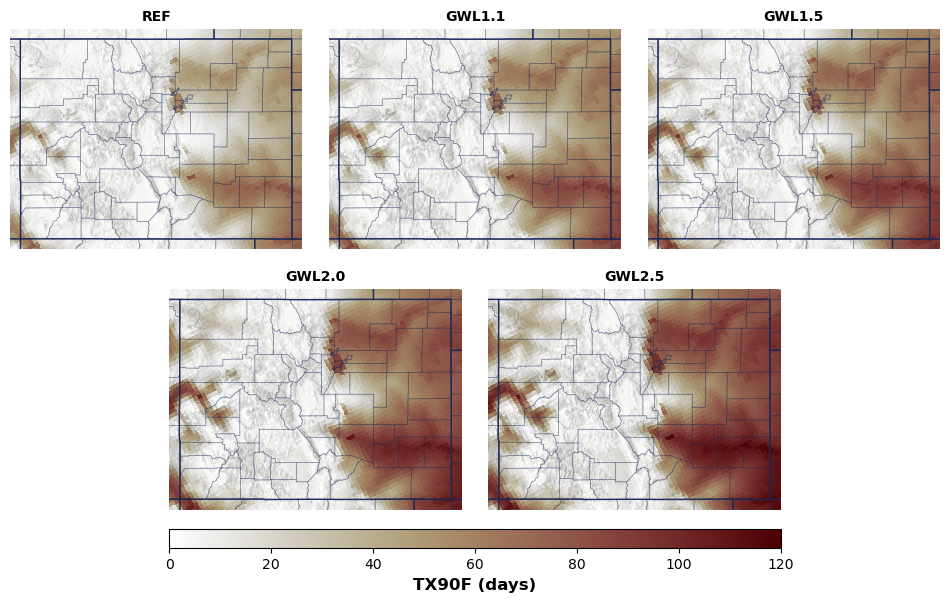

In [6]:
fig = plot_five_panel({
    "a": {"label": "REF", "key": "TX90F_REF_actual_values"},
    "b": {"label": "GWL1.1", "key": "TX90F_GWL11C_actual_values"},
    "c": {"label": "GWL1.5", "key": "TX90F_GWL15C_actual_values"},
    "d": {"label": "GWL2.0", "key": "TX90F_GWL20C_actual_values"},
    "e": {"label": "GWL2.5", "key": "TX90F_GWL25C_actual_values"},
})
plt.show()  # NOTE: if you are saving this, be sure to save at a high dpi (e.g., at least 300)
plt.close(fig)